In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

2025-06-30 06:50:37.547110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751246437.568310 2545285 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751246437.574869 2545285 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-30 06:50:37.597487: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1751246439.757511 2545285 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


In [7]:
from TFDWT.DWT1DFB import DWT1D, IDWT1D

In [2]:
x = tf.constant([1,2,3,1,1,1,1,1], dtype=tf.float32)
x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,1,0,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
x = tf.constant([0,0,1,0], dtype=tf.float32)
x = tf.constant([3.,7.], dtype=tf.float32)




# x = [0,0,0,0,1,1,1,1]
# wave = 'haar'
# wave = 'db2'
# wave = 'db3'

## filter init
# h = tf.constant([1,0,1,1], dtype=tf.float32)
h = tf.constant([1.,5.], dtype=tf.float32)
## Matching filter size with input size with zero padding
L = h.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = len(x)
paddings = [
           [0, Npoint - L],  # Depth dimension
        ]
h_padded = tf.pad(h, paddings, mode='CONSTANT', constant_values=0)
h_padded.shape


## Creating x[n-k] for all n
N = Npoint
n = tf.range(N)
row_indices = tf.math.mod(n[:, tf.newaxis]-n, N)
print(row_indices)
h_rows_shifted = tf.gather(h_padded, row_indices, axis=0)
print(x.shape, h_padded.shape, h_rows_shifted.shape), 
x, h_padded, h_rows_shifted

tf.Tensor(
[[0 1]
 [1 0]], shape=(2, 2), dtype=int32)
(2,) (2,) (2, 2)


(<tf.Tensor: shape=(2,), dtype=float32, numpy=array([3., 7.], dtype=float32)>,
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 5.], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[1., 5.],
        [5., 1.]], dtype=float32)>)

In [1252]:
# tf.reverse(tf.reverse(tf.math.mod(n[:, tf.newaxis] - n, N), axis=[0]), axis=[-1])

In [13]:
res = []
for r in range(x.shape[0]):
    res.append(tf.reduce_sum(x * h_rows_shifted[r,:]))
y1n = tf.stack(res,axis=-1)
y1n

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([38., 22.], dtype=float32)>

In [1254]:
# tf.einsum('i,ij->i', h_padded.numpy().T,rows_shifted)

In [1255]:
# #%% verify
# x
# rows_shifted[1,:]
# tf.squeeze(x).shape
# tf.einsum('i,ij->j', tf.squeeze(x),rows_shifted), x, rows_shifted

In [14]:
tf.expand_dims(tf.cast(h_rows_shifted, dtype=tf.float32), axis=0)[0,:,0]

tf.transpose(tf.expand_dims(tf.cast(h_rows_shifted, dtype=tf.float32), axis=0), perm=[0,2,1])[0,:,0]

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 5.], dtype=float32)>

In [15]:
tf.transpose(tf.expand_dims(tf.cast(h_rows_shifted, dtype=tf.float32), axis=0), perm=[0,2,1])

<tf.Tensor: shape=(1, 2, 2), dtype=float32, numpy=
array([[[1., 5.],
        [5., 1.]]], dtype=float32)>

In [16]:
# _ = tf.expand_dims(tf.cast(rows_shifted, dtype=tf.float32), axis=0)
wave = 'haar'
# wave = 'db2'
_ = tf.transpose(tf.expand_dims(tf.cast(h_rows_shifted, dtype=tf.float32), axis=0), perm=[0,2,1])
h_init = IDWT1D(wave, clean=False)(_)
h_init




<tf.Tensor: shape=(1, 2, 2), dtype=float32, numpy=
array([[[ 4.2426405,  4.2426405],
        [-2.828427 ,  2.828427 ]]], dtype=float32)>

In [1259]:
# h_init[0,0,:]

In [1260]:
# Reverse the order of h[0, 1, :]
# tf.reverse(h_init, axis=[-1])

In [1261]:
# h_init = tf.reverse(h_init, axis=[-1])
# h_init

In [17]:
tf.transpose(h_init, perm=[0,2,1])#[::-1]

<tf.Tensor: shape=(1, 2, 2), dtype=float32, numpy=
array([[[ 4.2426405, -2.828427 ],
        [ 4.2426405,  2.828427 ]]], dtype=float32)>

In [18]:
tf.transpose(h_init, perm=[0,2,1])[0,:,0]

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([4.2426405, 4.2426405], dtype=float32)>

In [19]:
h_init_T = tf.transpose(h_init, perm=[0,2,1])
H = DWT1D(wave, clean=False)(h_init_T)
print('H1 shape ',H.shape)
H
# H=H_T
## kernel ready

H1 shape  (1, 2, 2)


<tf.Tensor: shape=(1, 2, 2), dtype=float32, numpy=
array([[[ 5.9999995,  0.       ],
        [ 0.       , -3.9999998]]], dtype=float32)>

In [20]:
H.shape, H[0,:,0]
# H

(TensorShape([1, 2, 2]),
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([5.9999995, 0.       ], dtype=float32)>)

In [1266]:
# H = tf.reverse(H, axis=[-1])
# H

In [1267]:
# H = tf.transpose(H_T, perm=[0,2,1])
# H = H_T

In [21]:
_ = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
α = DWT1D(wave, clean=False)(_)
α.shape, α

(TensorShape([1, 2, 1]),
 <tf.Tensor: shape=(1, 2, 1), dtype=float32, numpy=
 array([[[ 7.071068 ],
         [-2.8284273]]], dtype=float32)>)

In [1269]:
# _ = tf.expand_dims(tf.expand_dims(h_padded, axis=0),axis=-1)
# wh = DWT1D(wave)(_)
# wh.shape,wh

In [1270]:
# IDWT1D(wave)(wh*α)
# wh*α

In [1271]:
# H*α

In [1272]:
# H,α

In [22]:
H[0:1,:,0:1] * α
H[0:1,:,1:2] * α
H[0:1,:,2:3] * α
H[0:1,:,3:4] * α

<tf.Tensor: shape=(1, 2, 0), dtype=float32, numpy=array([], shape=(1, 2, 0), dtype=float32)>

In [23]:
res_w = []
for k in range(H.shape[-1]):
    res_w.append(tf.reduce_sum(H[0:1,:,k:k+1] * α))
tf.stack(res_w,axis=-1)
# tf.reduce_sum(H[0:1,:,1:2] * α)
# tf.reduce_sum(H[0:1,:,2:3] * α)
# tf.reduce_sum(H[0:1,:,3:4] * α)

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([42.426403, 11.313708], dtype=float32)>

In [24]:
H.shape, α.shape

(TensorShape([1, 2, 2]), TensorShape([1, 2, 1]))

In [25]:
tf.einsum('bic,ij->bjc',α, tf.squeeze(H))

<tf.Tensor: shape=(1, 2, 1), dtype=float32, numpy=
array([[[42.426403],
        [11.313708]]], dtype=float32)>

In [26]:
β = tf.einsum('bic,ij->bjc',α, tf.squeeze(H))
β.shape
β
y1 = IDWT1D(wave, clean=False)(β)
y1.shape,y1

(TensorShape([1, 2, 1]),
 <tf.Tensor: shape=(1, 2, 1), dtype=float32, numpy=
 array([[[37.999996],
         [21.999996]]], dtype=float32)>)

In [1278]:
# y1 = tf.reverse(y1, axis=[1])
# y1

(<Axes: >, <StemContainer object of 3 artists>)

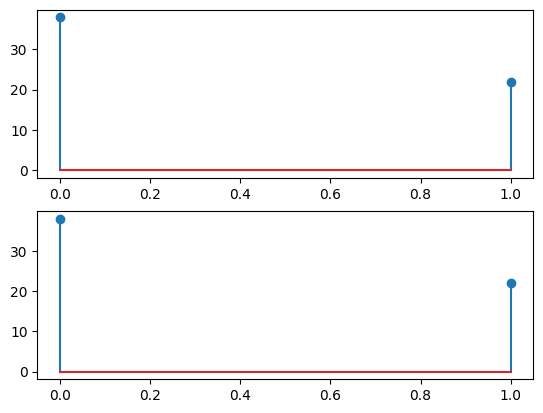

In [27]:
import matplotlib.pyplot as plt
plt.subplot(211), plt.stem(y1n)
plt.subplot(212), plt.stem(tf.squeeze(y1).numpy())
#plt.subplot(212), plt.stem(tf.squeeze(IDWT1D(wave)(wh*α)).numpy())


In [28]:
tf.reduce_sum(tf.abs(y1n)), tf.reduce_sum(tf.abs(y1)), 

(<tf.Tensor: shape=(), dtype=float32, numpy=60.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=59.99999237060547>)

In [29]:
y1.numpy(), y1n.numpy()

(array([[[37.999996],
         [21.999996]]], dtype=float32),
 array([38., 22.], dtype=float32))

In [1282]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# plt.stem(tf.squeeze(y1).numpy()+tf.reduce_max(y1))

        Quadratic

In [30]:
h

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 5.], dtype=float32)>

In [35]:
import numpy as np
from TFDWT.DWT2DFB import DWT2D, IDWT2D

In [39]:
# %% Quadratic kernel (m=2)
"""Quadratic kernel"""
# x = [0,0,0,1,0,0,0,0]
# filter init
# h = tf.constant([1, 2, 1])
h2 = np.einsum('i,j->ij', h, h)
print(h2)
L = h.shape[0] #filter length
# n = tf.range(L) 
Npoint = x.shape[0]
# Npoint = len(x)
paddings = [
           [0, Npoint - L],  # Depth dimension
           [0, Npoint - L]
        ]
# x
Npoint, paddings
h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
print(h_padded)
h_padded.shape

# _ = tf.expand_dims(tf.expand_dims(h_padded, axis=0),axis=-1)
# _.shape
# from TFDWT3D.DWTIDWT2Dtfv1 import DWT2D, IDWT2D
# h_init = IDWT2D()(tf.cast(_, dtype=tf.float32))
# h_init


## creating h[n-k1,n-k2]
N = Npoint
n = tf.range(N)
# Create circular indices for all possible shifts
# row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
row_indices = tf.math.mod(n[:, tf.newaxis] - n, N)
h_rows_shifted = tf.gather(h_padded, row_indices, axis=0)         # [N, N, N]
h_rows_shifted
h_columns_shifted = tf.gather(h_rows_shifted, row_indices,   # [N, N, N]
                                axis=2, batch_dims=1)
h_columns_shifted, h_columns_shifted.shape

# h_init = IDWT2D(clean=False)(tf.expand_dims(tf.cast(rows_shifted, dtype=tf.float32), axis=0))
# h_init

[[ 1.  5.]
 [ 5. 25.]]
tf.Tensor(
[[ 1.  5.]
 [ 5. 25.]], shape=(2, 2), dtype=float32)


(<tf.Tensor: shape=(2, 2, 2), dtype=float32, numpy=
 array([[[ 1.,  5.],
         [ 5., 25.]],
 
        [[25.,  5.],
         [ 5.,  1.]]], dtype=float32)>,
 TensorShape([2, 2, 2]))

In [1183]:
x.shape

TensorShape([2])

In [38]:
# %% Quadratic kernel (m=2)
"""Quadratic kernel"""
# x = [0,0,0,1,0,0,0,0]
# filter init
# h = tf.constant([1, 2, 1])
h2 = np.einsum('i,j->ij', h, h)
print(h2)
L = h.shape[0] #filter length
# n = tf.range(L) 
Npoint = x.shape[0]
# Npoint = len(x)
paddings = [
           [0, Npoint - L],  # Depth dimension
           [0, Npoint - L]
        ]
# x
Npoint, paddings
h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
print(h_padded)
h_padded.shape

# _ = tf.expand_dims(tf.expand_dims(h_padded, axis=0),axis=-1)
# _.shape
# from TFDWT3D.DWTIDWT2Dtfv1 import DWT2D, IDWT2D
# h_init = IDWT2D()(tf.cast(_, dtype=tf.float32))
# h_init


## creating h[n-k1,n-k2]
N = Npoint
n = tf.range(N)
# Create circular indices for all possible shifts
# row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
row_indices = tf.math.mod(n[:, tf.newaxis] - n, N)
rows_shifted = tf.gather(h_padded, row_indices, axis=0)         # [N, N, N]
rows_shifted
columns_shifted = tf.gather(rows_shifted, row_indices,   # [N, N, N]
                                axis=2, batch_dims=1)
columns_shifted, columns_shifted.shape

h_init = IDWT2D(clean=False)(tf.expand_dims(tf.cast(rows_shifted, dtype=tf.float32), axis=0))
h_init
## remember from NLSI theory of Volterra kernels and compute below
h_init = tf.concat([tf.expand_dims(tf.einsum('ijkl->il',h_init[:,:n,:n,:]), axis=1) for n in range(h_init.shape[1])], axis=1)
H2 = DWT1D(clean=False)(h_init)
H2, H2.shape


# x = tf.constant(x)
# x
# x = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
# x.shape
α = DWT1D(wave, clean=False)(tf.cast(x, dtype=tf.float32))
α.shape

## convolution like in wavelet domain
β = tf.einsum('bic,ij->bjc',α,tf.squeeze(H2))
β.shape
β
y2 = IDWT1D(wave, clean=False)(β)
y2.shape,y

# #%%
# alpha2 = α
# beta2 = β
# alpha2, beta2 
plt.figure(figsize=(2,5))
plt.subplot(3,1,1), plt.stem(tf.squeeze(x).numpy(),'k', basefmt="k"), plt.title(f'w. {wave}')
plt.subplot(3,1,2), plt.stem(tf.squeeze(y1).numpy(),'k', basefmt="k")
plt.subplot(3,1,3), plt.stem(tf.squeeze(y2).numpy(),'k', basefmt="k")
plt.tight_layout()
# tf.squeeze(x).numpy().shape, tf.squeeze(y).numpy().shape





[[ 1.  5.]
 [ 5. 25.]]
tf.Tensor(
[[ 1.  5.]
 [ 5. 25.]], shape=(2, 2), dtype=float32)


IndexError: tuple index out of range

In [9]:
#%%
# include ../dirx 
# mylibpath = '/home/k/PLAYGROUND10GB/myDTSPlib'
# mylibpath = '/home/k/PLAYGROUND10GB/kerasDWTLayer1D2D_orthogonal_wavelets.conv/FastDWTConvLayers/pypipackageTFDWT3d'
# import sys
# sys.path.insert(0,mylibpath)
# del mylibpath

import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import scipy
#import pywt
import numpy as np
# print(f"\
#     \n tf {tf.__version__}, \
#     \n matplotlib {matplotlib.__version__} \
#     \n scipy {scipy.__version__}\
#     \n pywavelets {pywt.__version__} (for comparing tf results)")

#### OKAY
# def get_A_matrix_dwt_analysisFB_unit(h0,h1,N:int):
#     """returns Analysis Matrix A"""
#     L = len(h0)
#     __H_branch_row = lambda h0,N: np.concatenate((h0, np.zeros(int(N - len(h0)))))
#     __H_start_row = lambda _row: np.roll(_row, shift=-L+2, axis=None)
#     __H_start_row(__H_branch_row(h0,N))
#     __H_branch= lambda _row: [np.roll(_row, shift=k*2, axis=None) for k in range(_row.shape[0]//2)]#-len(h0)+1)]
#     H0 = __H_branch(__H_start_row(__H_branch_row(h0,N)))
#     H1 = __H_branch(__H_start_row(__H_branch_row(h1,N)))
#     # return np.concatenate((H0[:int(len(H0)/2)], H1[:int(len(H1)/2)]))
#     return np.concatenate((H0, H1))

# A = get_A_matrix_dwt_analysisFB_unit(h0,h1,N)
# A.shape, A


## OK
# import pywt
from TFDWT3D.GETDWTFiltersOrtho import GETDWTFiltersOrtho
from TFDWT3D.get_A_matrix_dwt_analysisFB_unit import get_A_matrix_dwt_analysisFB_unit
@keras.saving.register_keras_serializable()
class DWT1D(tf.keras.layers.Layer):
    """1D DWT layer @kkt"""
    def __init__(self, wave='haar', **kwargs):
        super(DWT1D, self).__init__(**kwargs)
        w = GETDWTFiltersOrtho(wave)
        self.h0, self.h1 = w.analysis()
        self.L = len(self.h0)
        # self.padding_mode = 'symmetric' #reflect'
        # self.N
        # self.A
        
    def build(self, input_shape):
        self.num_channels = input_shape[-1]
        self.N = input_shape[1]
        self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # self.pw = (self.A.shape[0]-self.N)//2
        super(DWT1D, self).build(input_shape) 
       
    
    def call(self, inputs):
        # ch_ = [self.__pad(inputs[..., i:i+1]) for i in range(self.num_channels)]
        # ch_ = tf.concat(ch_, axis=-1)
        # ch_ = [self.__dwt(ch_[..., i:i+1]) for i in range(self.num_channels)]
        ch_ = [self.__dwt(inputs[..., i:i+1]) for i in range(self.num_channels)]
        out = tf.concat(ch_, axis=-1)
        #
        # out = self.__extract_2subbands(out)
        return out

    # @tf.function
    def __dwt(self, x):
        # print('>>',x.shape)
        x = tf.squeeze(x, axis=-1)
        dwtout = tf.cast(self.A, tf.float32)@tf.transpose(tf.cast(x, tf.float32), perm=[1,0])
        #OR einsum !!
        # dwtout = tf.einsum('ij,bjk->bik', tf.cast(self.A, tf.float32), tf.transpose(tf.cast(x, tf.float32), perm=[1,0]))
        dwtout = tf.transpose(dwtout,perm=[1,0])
        # print('++',dwtout.shape)
        return tf.expand_dims(dwtout, axis=-1)

    # def __pad(self, x):
    #     x = tf.squeeze(x, axis=-1)
    #     # paddings = tf.constant([[0,0], [self.pw, self.pw,], [self.pw, self.pw]])
    #     paddings = tf.constant([[0,0], [self.pw, self.pw]])

    #     x_padded = tf.pad(x, paddings, self.padding_mode)
    #     print('+',x_padded.shape) 
    #     # return x_padded
    #     return tf.expand_dims(x_padded, axis=-1)

    def __extract_2subbands(self,LH_padded):
        """returns 2 subbands L, H from DWT Analysis bank o/p --@k"""
     
        _mid = int(LH_padded.shape[1]/2)
        L = LH_padded[:,:_mid,:]
        H = LH_padded[:,_mid:,:]
        
        # _i = int((L.shape[1] - self.N/2)/2)
        # out = tf.concat([L[:,_i:-_i,:], H[:,_i:-_i,:]], axis=-1)
        out = tf.concat([L, H], axis=-1)
        return out

    # def compute_output_shape(self, input_shape):
    #     batch_size, height, width, channels = input_shape
    #     new_height, new_width = height // 2, width // 2
    #     return (batch_size, new_height, new_width, 4 * channels)
    
    def get_config(self):
        config = super(DWT1D, self).get_config()
        return config



# ## WORKING IDWT similar to wavetf
# import pywt
# from GETDWTFiltersOrtho import GETDWTFiltersOrtho
@keras.saving.register_keras_serializable()
class IDWT1D(tf.keras.layers.Layer):
    """1D IDWT layer @kkt"""
    def __init__(self, wave='haar', **kwargs):
        super(IDWT1D, self).__init__(**kwargs)
        w = GETDWTFiltersOrtho(wave)
        
        # self.biortho_flag = 0
        if 'bior' in wave or 'rbio' in wave:
            """BIORTHOGONAL wavelets"""
            # self.g0, self.g1 = w.synthesis()
            # self.h0, self.h1 = self.g0, self.g1
            # del self.g0, self.g1
            self.h0, self.h1 = w.synthesis()
            # self.biortho_flag = 1
            print(f"Biothogonal wavelet {wave}")
        else:
            """ORTHOGONAL wavelets"""
            self.h0, self.h1 = w.analysis()
        
        # g0, g1 = w.synthesis()
        self.L = len(self.h0)
        # self.padding_mode = 'symmetric'#'reflect'#

    def build(self, input_shape):
        self.num_channels = input_shape[-1]
        self.N = int(input_shape[1])#*2)
        self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # if self.biortho_flag:
            # self.S = get_A_matrix_dwt_analysisFB_unit(self.g0,self.g1,self.N)
        # self.pw = int(self.L/2)
        super(IDWT1D, self).build(input_shape) 

    def call(self, inputs):
        # self.N = int(inputs.shape[1]*2)
        # self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # input_shape = tf.shape(inputs)

        #all input channels
        # ch_ = tf.unstack(inputs, axis=-1)
        # print(len(ch_))
        # ch_ = tf.stack([self.__pad(_) for _ in ch_], axis=-1)
        # __ = self.__splitch_for_idwt(ch_)
        # print('+', self.__idwt(inputs[..., 0:0+1]).shape)
        # __ = self.__splitch_for_idwt(inputs)
        # print('++', __[0].shape)
        # __ = [self.__rejoin(_) for _ in __]# axis=-1)
        # print('++', __[0].shape)
        # out = tf.stack([self.__idwt(_) for _ in __], axis=-1)

        ch_ = [self.__idwt(inputs[..., i:i+1]) for i in range(self.num_channels)]
        out = tf.stack(ch_, axis=-1)
        # print('+++', out.shape)
        # out = ch_
        # L = self.L
        return out#[:,L:-L,:]

    @tf.function
    def __idwt(self, x_dwtcoeffs):
        __ = x_dwtcoeffs
        # print('++', type(__))
        __ = tf.squeeze(__, axis=-1)
        # print('+++', __[0].shape)
        # perm=[1,0]
        # print('+++', __.shape)
        # if self.biortho_flag:
        #     """BIORTHOGONAL wavelet"""
        #     idwtout = tf.cast(self.A.T, tf.float32) @ tf.transpose(__,perm=[1,0])
        #     # idwtout = tf.transpose(idwtout,perm=[1,0])
        # else:
        #     """ORTHOGONAL wavelet"""
        idwtout = tf.cast(self.A.T, tf.float32) @ tf.transpose(__,perm=[1,0])
        idwtout = tf.transpose(idwtout,perm=[1,0])
        
        # idwtout = tf.expand_dims(idwtout)
      
        return idwtout#[L:-L,L:-L,:]
        
    
    # def __pad(self, x):
    #     paddings = tf.constant([[0,0], [self.pw, self.pw,]])
    #     x_padded = tf.pad(x, paddings, self.padding_mode)
    #     # print('+',x_padded.shape) 
    #     return x_padded

    def __splitch_for_idwt(self,x):
        w = int(x.shape[-1]/2)
        __ = [tf.stack([x[:,:,k], x[:,:,k+1*w]],  axis=-1) for k in range(w)]
        return __
    #__ = __splitch_for_idwt(coeffs)

    def __rejoin(self,subbands):
        el = tf.unstack(subbands, axis=-1)
        # print('++++', el)
        _1 = tf.concat([el[0][:,:], el[1][:,:]], axis=-1)
        # print('+++++', _1.shape)
        # _1.shape
        # _2 = tf.concat([el[1][:,:,:], el[3][:,:,:]], axis=-1)
        # _1.shape
        # _ = tf.concat([_1, _2], axis=-2)
        # _.shape
        return _1
    #tf.stack([rejoin(_) for _ in __], axis=-1)

    # def compute_output_shape(self, input_shape):
    #     batch_size, height, width, channels = input_shape
    #     new_height, new_width, new_channels = height *2, width *2, channels //4
    #     return (batch_size, new_height, new_width, new_channels)
   
    def get_config(self):
        config = super(IDWT1D, self).get_config()
        return config

In [1142]:
#%% 
### new with einsum operations
"""Fixed the DWT and IDWT matrix.
The matrix is of same dimension as of the signal. No padding is applied.
Circular convolution takes care of the boundary effects. @KKT 14/03/2024 """

# include ../dirx 
# mylibpath = '/home/k/PLAYGROUND10GB/myDTSPlib'
# mylibpath = '/home/k/PLAYGROUND10GB/kerasDWTLayer1D2D_orthogonal_wavelets.conv/FastDWTConvLayers/pypipackageTFDWT3d'
# import sys
# sys.path.insert(0,mylibpath)
# del mylibpath

import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import scipy
# import pywt
import numpy as np
# print(f"\
#     \n tf {tf.__version__}, \
#     \n matplotlib {matplotlib.__version__} \
#     \n scipy {scipy.__version__}\
#     \n pywavelets {pywt.__version__} (for comparing tf results)")


# def get_A_matrix_dwt_analysisFB_unit(h0,h1,N:int):
#     """returns Analysis Matrix A"""
#     L = len(h0)
#     __H_branch_row = lambda h0,N: np.concatenate((h0, np.zeros(int(N - len(h0)))))
#     __H_start_row = lambda _row: np.roll(_row, shift=-L+2, axis=None)
#     __H_start_row(__H_branch_row(h0,N))
#     __H_branch= lambda _row: [np.roll(_row, shift=k*2, axis=None) for k in range(_row.shape[0])]#-len(h0)+1)]
#     H0 = __H_branch(__H_start_row(__H_branch_row(h0,N)))
#     H1 = __H_branch(__H_start_row(__H_branch_row(h1,N)))
#     return np.concatenate((H0[:int(len(H0)/2)], H1[:int(len(H1)/2)]))

# A = get_A_matrix_dwt_analysisFB_unit(h0,h1,N)
# A.shape, A


## OK
# import pywt
from TFDWT3D.GETDWTFiltersOrtho import GETDWTFiltersOrtho
from TFDWT3D.get_A_matrix_dwt_analysisFB_unit import get_A_matrix_dwt_analysisFB_unit
@keras.saving.register_keras_serializable()
class DWT2D(tf.keras.layers.Layer):
    """2D DWT layer @kkt"""
    def __init__(self, wave='haar', **kwargs):
        super(DWT2D, self).__init__(**kwargs)
        w = GETDWTFiltersOrtho(wave)
        self.h0, self.h1 = w.analysis()
        # g0, g1 = w.synthesis()
        self.L = len(self.h0)
        # self.padding_mode = 'symmetric'
        # self.N
        # self.A
        
    def build(self, input_shape):
        self.num_channels = input_shape[-1]
        self.N = input_shape[1]
        self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # self.pw = (self.A.shape[0]-self.N)//2
        super(DWT2D, self).build(input_shape) 
       
    
    def call(self, inputs):
        # ch_ = [self.__pad(inputs[..., i:i+1]) for i in range(self.num_channels)]
        # ch_ = tf.concat(ch_, axis=-1)
        # ch_ = [self.__dwt(ch_[..., i:i+1]) for i in range(self.num_channels)]
        ch_ = [self.__dwt(inputs[..., i:i+1]) for i in range(self.num_channels)]
        out = tf.concat(ch_, axis=-1)
        #
        # out = self.__extract_4subbands(out)
        return out

    @tf.function
    def __dwt(self, x):
        # print('>>',x.shape)
        # x = tf.squeeze(x, axis=-1)
        # _ = tf.transpose(x, perm=[0,2,1])
        # _rowconv_out = tf.cast(self.A, tf.float32)@tf.cast(_, tf.float32)
        # _colconv_out = tf.cast(self.A, tf.float32)@tf.transpose(_rowconv_out, perm=[0,2,1])
        # _LLLHHLHH = _colconv_out
        ## end dwt



        ## einsum code
        _x2d = tf.squeeze(x, axis=-1)
        _x2d = tf.transpose(_x2d,[0,2,1])
        A = tf.cast(self.A, tf.float32)
        _rowconv_out = tf.einsum('ij,bjk->bik', A, _x2d)
        _rowconv_outT = tf.transpose(_rowconv_out,[0,2,1])
        _LLLHHLHH = tf.einsum('ij,bjk->bik', A, _rowconv_outT)
        _colconv_out = _LLLHHLHH
        # _LLLHHLHH.shape
        # plt.imshow(_LLLHHLHH)
        ## einsum code end








        # OK for batch   
        # perm=[1,2,0]#ok but rotate 90
        # __ = tf.cast(self.A, tf.float32)@tf.transpose(_rowconv_out, perm=perm)
       
        # perm=[2,1,0]
        # __ = tf.transpose(__, perm=perm)
        # print('*T',__.shape)
        
        # plt.imshow(__[1,:,:]), plt.show()
        # plt.imshow(__[0,:,:]), plt.show()
        # return __
        return tf.expand_dims(_colconv_out, axis=-1)

    # def __pad(self, x):
    #     x = tf.squeeze(x, axis=-1)
    #     paddings = tf.constant([[0,0], [self.pw, self.pw,], [self.pw, self.pw]])

    #     x_padded = tf.pad(x, paddings, self.padding_mode)
    #     # print('+',x_padded.shape) 
    #     # return x_padded
    #     return tf.expand_dims(x_padded, axis=-1)

    def __extract_4subbands(self,LLLHHLHH):
        """returns 4 image subbands LL, LH, HL, HH from DWT Analysis bank o/p --@k"""
        # global N
        _mid = int(LLLHHLHH.shape[1]/2)
        LL = LLLHHLHH[:,:_mid,:_mid,:]
        LH = LLLHHLHH[:,_mid:,:_mid,:]
        HL = LLLHHLHH[:,:_mid,_mid:,:]
        HH = LLLHHLHH[:,_mid:,_mid:,:]
        # _i = int((LL.shape[1] - self.N/2)/2)
        # out = tf.concat([LL[:,_i:-_i,_i:-_i,:], LH[:,_i:-_i,_i:-_i,:], HL[:,_i:-_i,_i:-_i,:], HH[:,_i:-_i,_i:-_i,:]], axis=-1)
        out = tf.concat([LL, LH, HL, HH], axis=-1)
        return out

    # def compute_output_shape(self, input_shape):
    #     batch_size, height, width, channels = input_shape
    #     new_height, new_width = height // 2, width // 2
    #     return (batch_size, new_height, new_width, 4 * channels)
    
    def get_config(self):
        config = super(DWT2D, self).get_config()
        return config



# ## WORKING IDWT similar to wavetf
# import pywt
# from GETDWTFiltersOrtho import GETDWTFiltersOrtho
@keras.saving.register_keras_serializable()
class IDWT2D(tf.keras.layers.Layer):
    """2D IDWT layer @kkt"""
    def __init__(self, wave='haar', **kwargs):
        super(IDWT2D, self).__init__(**kwargs)
        w = GETDWTFiltersOrtho(wave)
        if 'bior' in wave or 'rbio' in wave:
            """BIORTHOGONAL wavelets"""
            # self.g0, self.g1 = w.synthesis()
            # self.h0, self.h1 = self.g0, self.g1
            # del self.g0, self.g1
            self.h0, self.h1 = w.synthesis()
            # self.biortho_flag = 1
            # print(f"Biothogonal wavelet {wave}")
        else:
            """ORTHOGONAL wavelets"""
            self.h0, self.h1 = w.analysis()
        # g0, g1 = w.synthesis()
        self.L = len(self.h0)
        # self.padding_mode = 'symmetric'

    def build(self, input_shape):
        self.num_channels = input_shape[-1]
        self.N = int(input_shape[1])
        self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # self.pw = int(self.L/2)
        super(IDWT2D, self).build(input_shape) 

    def call(self, inputs):
        # self.N = int(inputs.shape[1]*2)
        # self.A = get_A_matrix_dwt_analysisFB_unit(self.h0,self.h1,self.N)
        # input_shape = tf.shape(inputs)

        #all input channels
        # ch_ = tf.unstack(inputs, axis=-1)
        # print(len(ch_))
        # ch_ = tf.stack([self.__pad(_) for _ in ch_], axis=-1)
        # __ = self.__splitch_for_idwt(ch_)
        # __ = self.__splitch_for_idwt(inputs)
        # __ = [self.__rejoin(_) for _ in __]# axis=-1)

        # out = tf.stack([self.__idwt(_) for _ in __], axis=-1)

        ch_ = [self.__idwt(inputs[..., i:i+1]) for i in range(self.num_channels)]
        # print('+', h_[0].shape)
        out = tf.stack(ch_, axis=-1)
        # out = ch_
        # L = self.L
        return out#[:,L:-L,L:-L,:]

    @tf.function
    def __idwt(self, x_dwtcoeffs):
        # __ = x_dwtcoeffs
        # _r = tf.transpose(__, perm=[0,2,1])
        # _r = tf.cast(self.A.T, tf.float32) @ _r
        # ans = self.A.T@tf.transpose(_r,perm=[0,2,1])
        # # print('*', ans.shape)
        # # plt.imshow(ans[0,:,:]), plt.show()
        # return ans#[L:-L,L:-L,:]
        x_dwtcoeffs = tf.squeeze(x_dwtcoeffs, axis=-1)
        _LLLHHLHH = x_dwtcoeffs
        A = tf.cast(self.A, tf.float32)
        # print('>',x_dwtcoeffs.shape)
        
        _ = tf.transpose(_LLLHHLHH,[0,2,1])
        # print('>>', _.shape)
        _AT = tf.cast(tf.transpose(A,[1,0]), dtype=tf.float32)
        # print('>>',_AT.shape, _.shape)
        _r = tf.einsum('ij,bjk->bik', _AT, _)
        _rT = tf.transpose(_r,[0,2,1])
        _r = tf.einsum('ij,bjk->bik', _AT, _rT)
        # plt.imshow(_r)
        # _LLLHHLHH.dtype, _AT.dtype, _r.shape
        # print('+>',_r.shape)
        return _r
        
    
    # def __pad(self, x):
    #     paddings = tf.constant([[0,0], [self.pw, self.pw,], [self.pw, self.pw]])
    #     x_padded = tf.pad(x, paddings, self.padding_mode)
    #     # print('+',x_padded.shape) 
    #     return x_padded

    def __splitch_for_idwt(self,x):
        w = int(x.shape[-1]/4)
        __ = [tf.stack([x[:,:,:,k], x[:,:,:,k+1*w], x[:,:,:,k+2*w], x[:,:,:,k+3*w]],  axis=-1) for k in range(w)]
        return __
    #__ = __splitch_for_idwt(coeffs)

    def __rejoin(self,subbands):
        el = tf.unstack(subbands, axis=-1)
        _1 = tf.concat([el[0][:,:,:], el[2][:,:,:]], axis=-1)
        _1.shape
        _2 = tf.concat([el[1][:,:,:], el[3][:,:,:]], axis=-1)
        _1.shape
        _ = tf.concat([_1, _2], axis=-2)
        _.shape
        return _
    #tf.stack([rejoin(_) for _ in __], axis=-1)

    # def compute_output_shape(self, input_shape):
    #     batch_size, height, width, channels = input_shape
    #     new_height, new_width, new_channels = height *2, width *2, channels //4
    #     return (batch_size, new_height, new_width, new_channels)
   
    def get_config(self):
        config = super(IDWT2D, self).get_config()
        return config
    